In [1]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import cartopy.feature as cfeature
import cartopy.crs as ccrs

In [2]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [3]:
# Abramov Glacier coordinates:
abra_lat = 39.66
abra_lon = 71.50

In [4]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [5]:
domain_2 = 'GRp'
# domain_3 = 'GRp_bug'

In [6]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
# sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [7]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [8]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve le glacier Abramov

# distance sur grille
dist = np.sqrt((ds_lat - abra_lat)**2 + (ds_lon - abra_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)

print("Caratéristique de la maille MAR ou se trouve le glacier Abramov")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le glacier Abramov
Indice Y : 44
Indice X : 37
Latitude : 39.67844009399414
Longitude : 71.48213958740234
Altitude : 4171.5380859375


/tmp/ipykernel_103988/1803992992.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


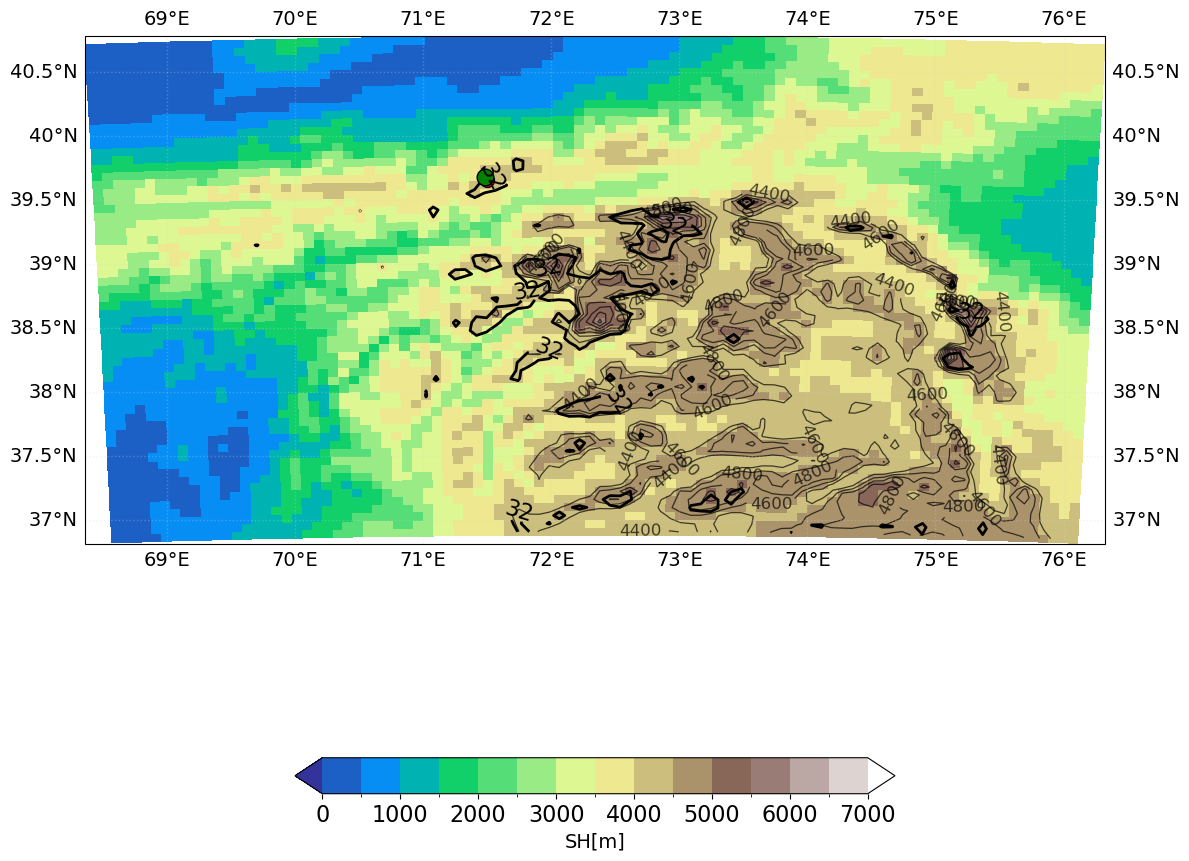

In [9]:
ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

# ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
#             levels=[10,ice_level,100],
#             hatches=['','X','X'],
#             colors="none",
#             transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[4400,4600,4800,5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000],
                             colors="k", linewidths=0.9, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
# ax.set_extent([71, 72, 39.4, 40], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Abramov Glacier: red dot
ax.plot(abra_lon, abra_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# Identifier le point de grille ou se trouve la carotte Jasgulem
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())

plt.show()

/tmp/ipykernel_103988/1724372153.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


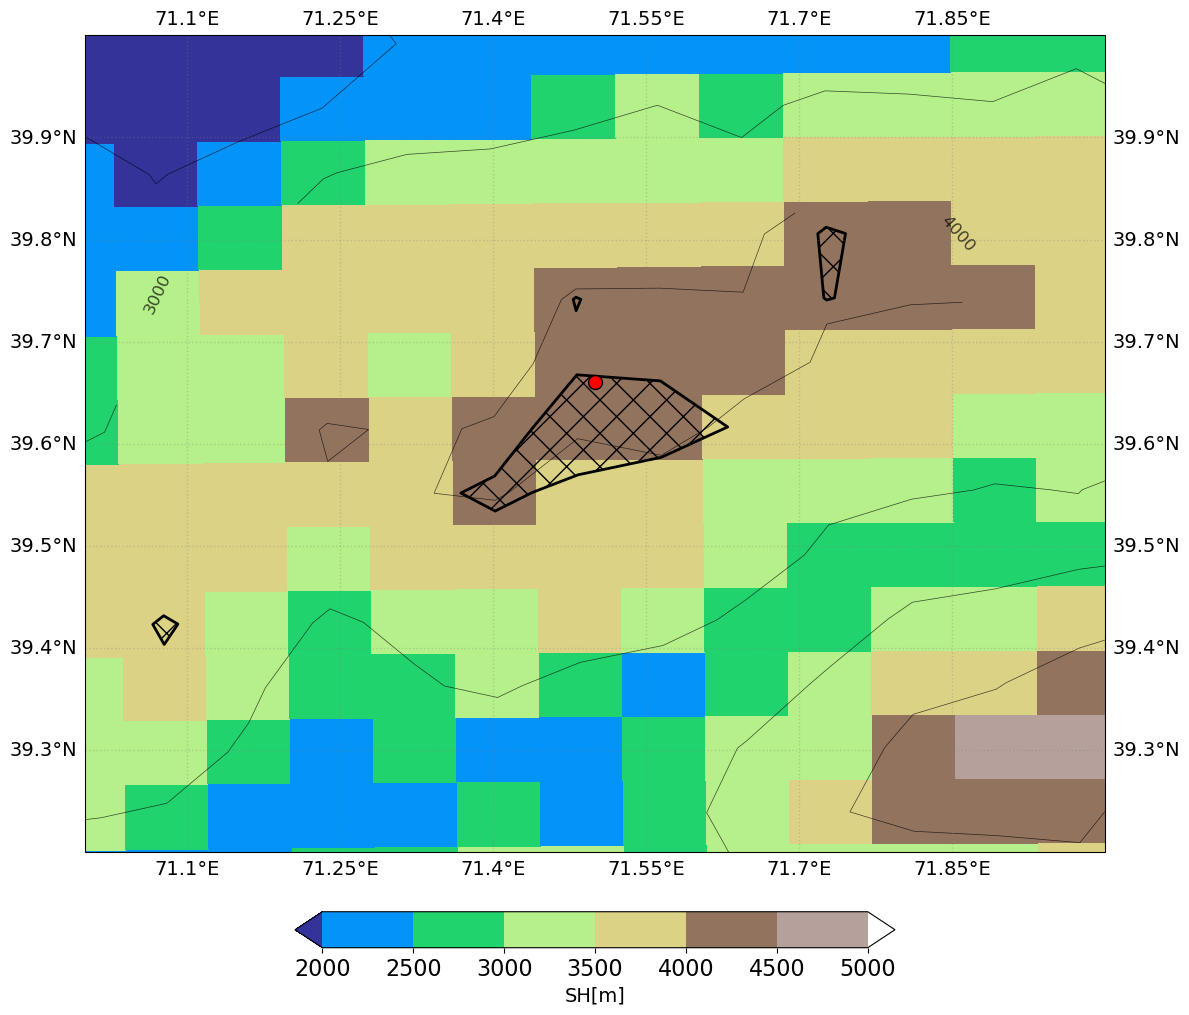

In [11]:
ice_level=40# % of ice on grid cell

clevs=np.arange(2000,5500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

# Latitude : 39.67844009399414
# Longitude : 71.48213958740234
ax.set_extent([71, 72, 39.2, 40], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Abramov Glacier : red dot
ax.plot(abra_lon, abra_lat,
        marker='o', markersize=10,
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

plt.show()



### MAR datasets

# A ajouter ici : ds_SW mon mean


In [13]:
variable='TTZ'

ds_TTZ = xr.open_mfdataset(sourceData_1 + "TTZ_monmean_MARv3.14_ER5_spin2_GRp_*.nc").isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [14]:
variable='RF'

ds_RF = xr.open_mfdataset(sourceData_1 + "RF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [15]:
variable='SF'

ds_SF = xr.open_mfdataset(sourceData_1 + "SF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [16]:
variable='ME' 

ds_ME = xr.open_mfdataset(sourceData_1 + "ME_monsum_MARv3.14_ER5_spin2_GRp_*.nc").ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]
ds_ME = - ds_ME

In [17]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

ds_SMB = xr.open_mfdataset(sourceData_1 + "SMB_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

In [18]:
variable='SW' 
# Surface Water

ds_SW = xr.open_mfdataset(sourceData_1 + "SW_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SW.isel(SECTOR1_1=0).load()

ds_SW = ds_SW.assign_coords(X=np.round(ds_SW.X.values))
ds_SW = ds_SW.assign_coords(Y=np.round(ds_SW.Y.values))
ds_SW = ds_SW.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SW = ds_SW[:,k:-k,k:-k]

In [19]:
variable='RU' 
# Run Off

ds_RU = xr.open_mfdataset(sourceData_1 + "RU_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RU.isel(SECTOR=0).load()

ds_RU = ds_RU.assign_coords(X=np.round(ds_RU.X.values))
ds_RU = ds_RU.assign_coords(Y=np.round(ds_RU.Y.values))
ds_RU = ds_RU.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RU = ds_RU[:,k:-k,k:-k]

In [20]:
variable='RZ' 
# Refreezing // il faut un monSUM pour RW

ds_RZ = xr.open_mfdataset(sourceData_1 + "RZ_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RZ.isel(SECTOR1_1=0).load()

ds_RZ = ds_RZ.assign_coords(X=np.round(ds_RZ.X.values))
ds_RZ = ds_RZ.assign_coords(Y=np.round(ds_RZ.Y.values))
ds_RZ = ds_RZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RZ = ds_RZ[:,k:-k,k:-k]

In [21]:
variable='SU' 
# SMB = SF - ME +RZ - SU - SW

ds_SU = -(ds_SF - (-ds_ME) + ds_RZ - ds_SW - ds_SMB)

## Sorties de MAR au point de Grille Abramov Glacier

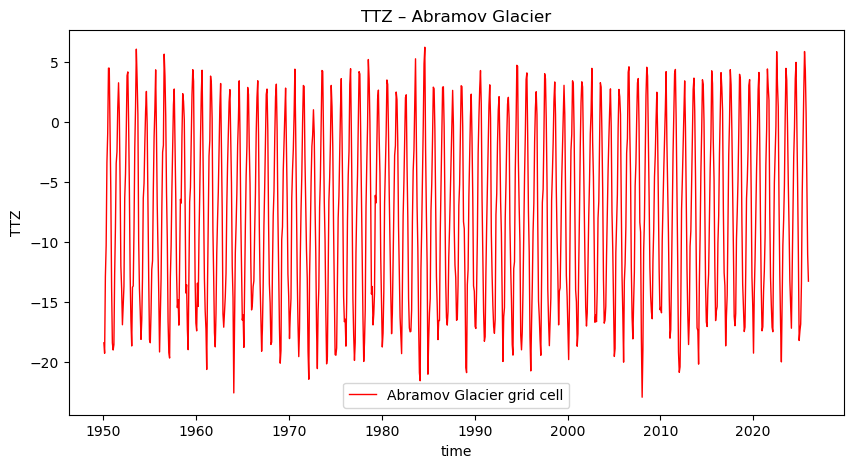

In [22]:
# TTZ at Jasgulem ice core site

plt.figure(figsize=(10,5))

ds_TTZ_abra =  ds_TTZ.isel(Y=iY, X=iX)
ds_TTZ_abra.plot(label="Abramov Glacier grid cell", linewidth=1, color="red")

plt.legend(ncol=3)
plt.title("TTZ – Abramov Glacier")
plt.ylabel("TTZ")
plt.show()

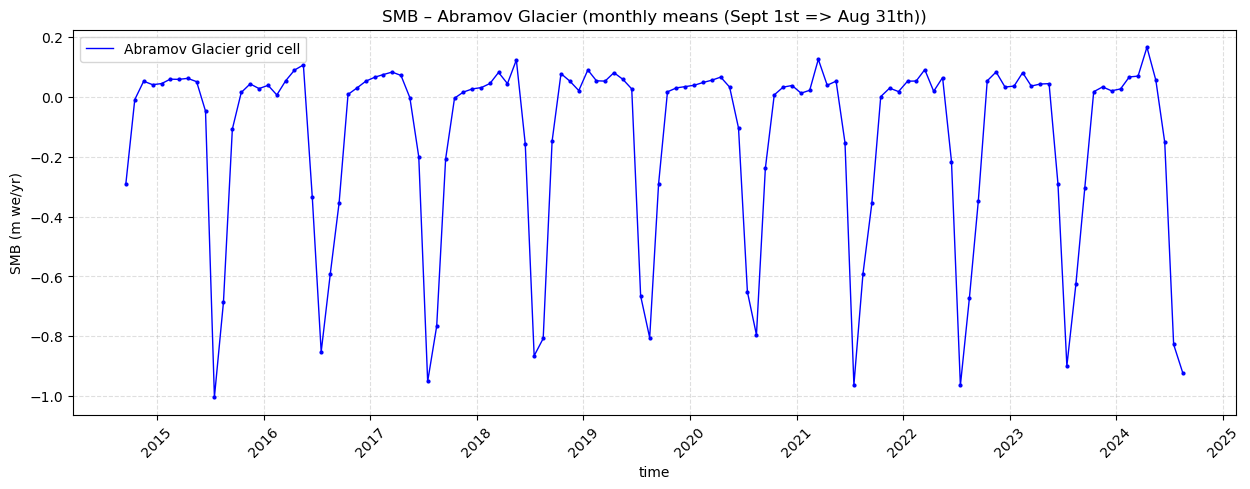

In [23]:
#SMB mensuel 

plt.figure(figsize=(15,5))

# Point précis Jasgulem
ds_SMB_abra = ds_SMB.isel(Y=iY, X=iX).sel(time=slice("2014-09-01", "2024-08-31"))/1000
# ds_SMB_abra_annual = ds_SMB_abra.resample(time="A-SEP").sum().sel(time=slice("1980-09-01", "2024-08-31"))/1000

ds_SMB_abra.plot(label="Abramov Glacier grid cell", linewidth=1, color="blue")

plt.plot(ds_SMB_abra.time,
         ds_SMB_abra,
         'o', color='blue', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Abramov Glacier (monthly means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

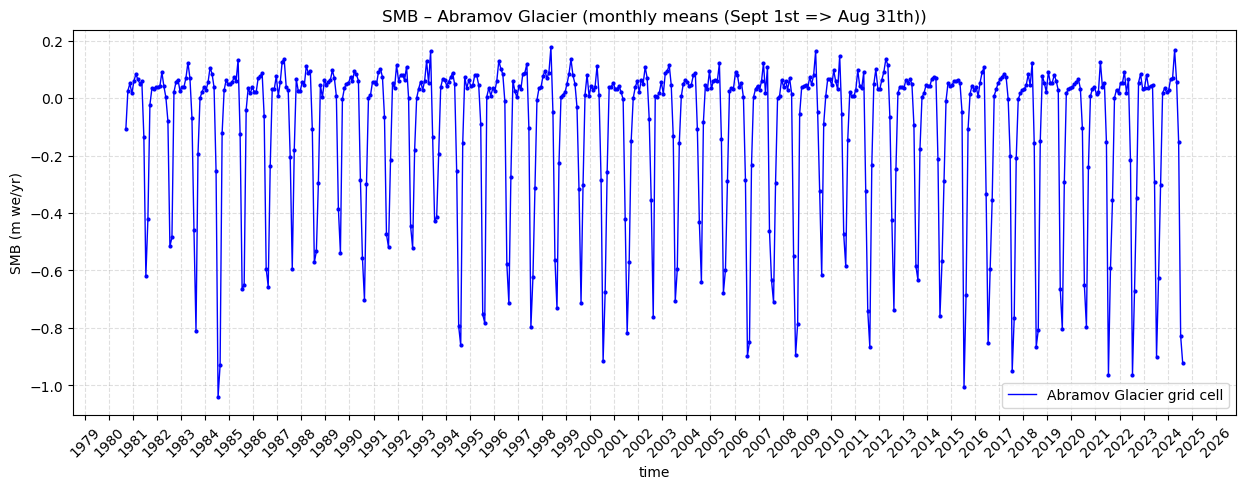

In [24]:
#SMB mensuel 

plt.figure(figsize=(15,5))

# Point précis Jasgulem
ds_SMB_abra = ds_SMB.isel(Y=iY, X=iX).sel(time=slice("1980-09-01", "2024-08-31"))/1000
# ds_SMB_abra_annual = ds_SMB_abra.resample(time="A-SEP").sum().sel(time=slice("1980-09-01", "2024-08-31"))/1000

ds_SMB_abra.plot(label="Abramov Glacier grid cell", linewidth=1, color="blue")

plt.plot(ds_SMB_abra.time,
         ds_SMB_abra,
         'o', color='blue', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Abramov Glacier (monthly means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-SEP' is deprecated and will be removed in a future version, please use 'YE-SEP' instead.
  self.index_grouper = pd.Grouper(


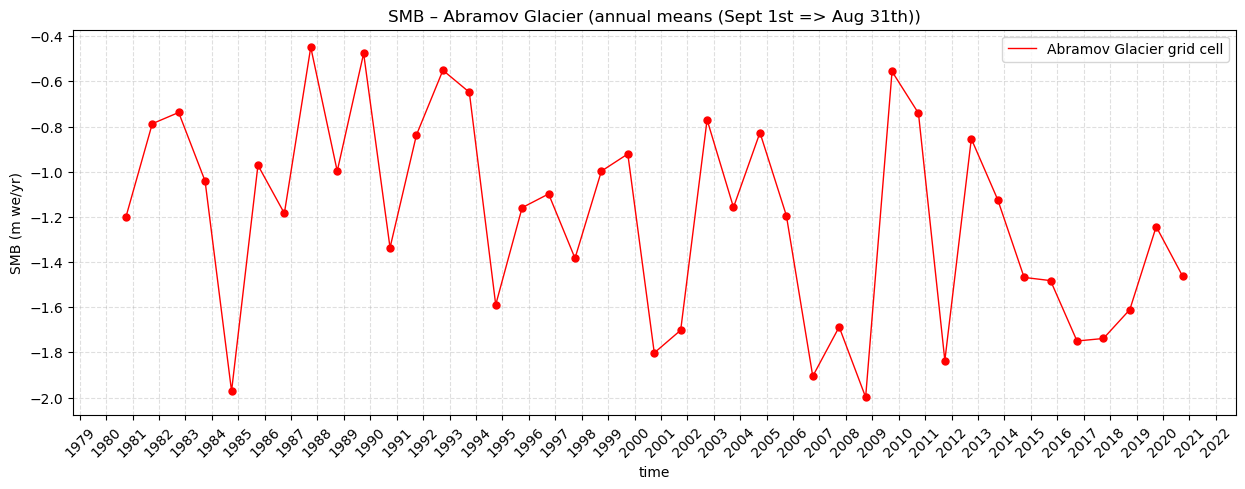

In [25]:
#SMB Annual (from Sept 1 to Aug 31)

plt.figure(figsize=(15,5))

# Point précis Jasgulem
ds_SMB_abra = ds_SMB.isel(Y=iY, X=iX)
ds_SMB_abra_annual = ds_SMB_abra.resample(time="A-SEP").sum().sel(time=slice("1980-09-01", "2021-08-31"))/1000

ds_SMB_abra_annual.plot(label="Abramov Glacier grid cell", linewidth=1, color="red")

plt.plot(ds_SMB_abra_annual.time,
         ds_SMB_abra_annual,
         'o', color='red', markersize=5)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Abramov Glacier (annual means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'AS-SEP' is deprecated and will be removed in a future version, please use 'YS-SEP' instead.
  self.index_grouper = pd.Grouper(


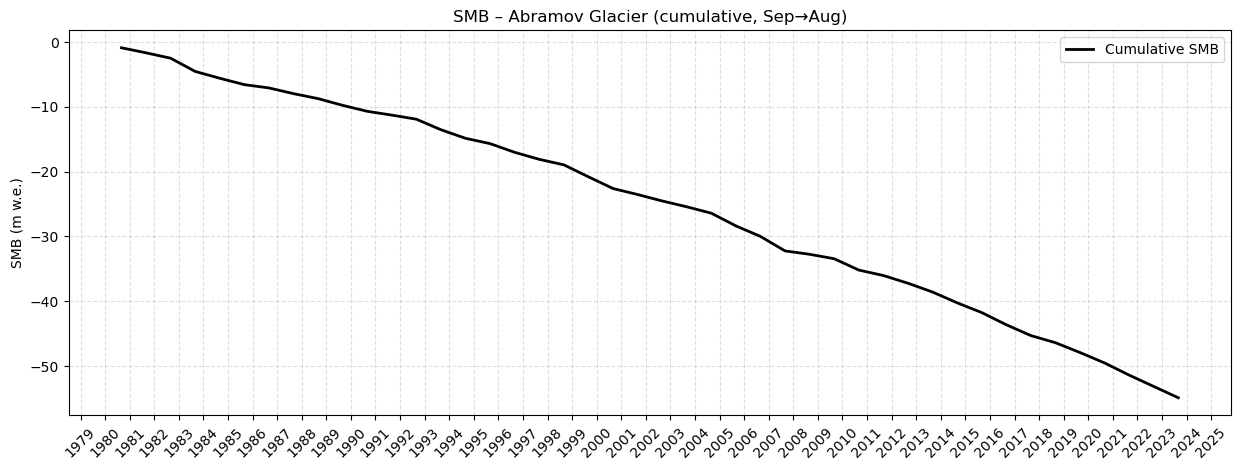

In [26]:
# =========================
# SMB annuel (Sep → Aug)
# =========================

ds_SMB_abra = ds_SMB.isel(Y=iY, X=iX)

ds_SMB_abra_annual = (
    ds_SMB_abra
    .resample(time="AS-SEP")
    .sum()
    .sel(time=slice("1980-09-01", "2024-08-31"))
    / 1000  # m w.e.
)

# =========================
# CUMUL SMB
# =========================

ds_SMB_cum = ds_SMB_abra_annual.cumsum(dim="time")

# =========================
# PLOT
# =========================

plt.figure(figsize=(15,5))

plt.plot(
    ds_SMB_cum.time,
    ds_SMB_cum,
    '-',
    color='black',
    linewidth=2,
    label="Cumulative SMB"
)

# =========================
# AXES
# =========================

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title("SMB – Abramov Glacier (cumulative, Sep→Aug)")
plt.ylabel("SMB (m w.e.)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()

## Composantes du SMB

In [27]:
# SMB = SF - ME + RZ - SU - SW

smb_dataset = {
    "SF": ds_SF,
    "ME": ds_ME,  
    "RZ": ds_RZ,
    "SU": ds_SU,
    "SW": ds_SW
}

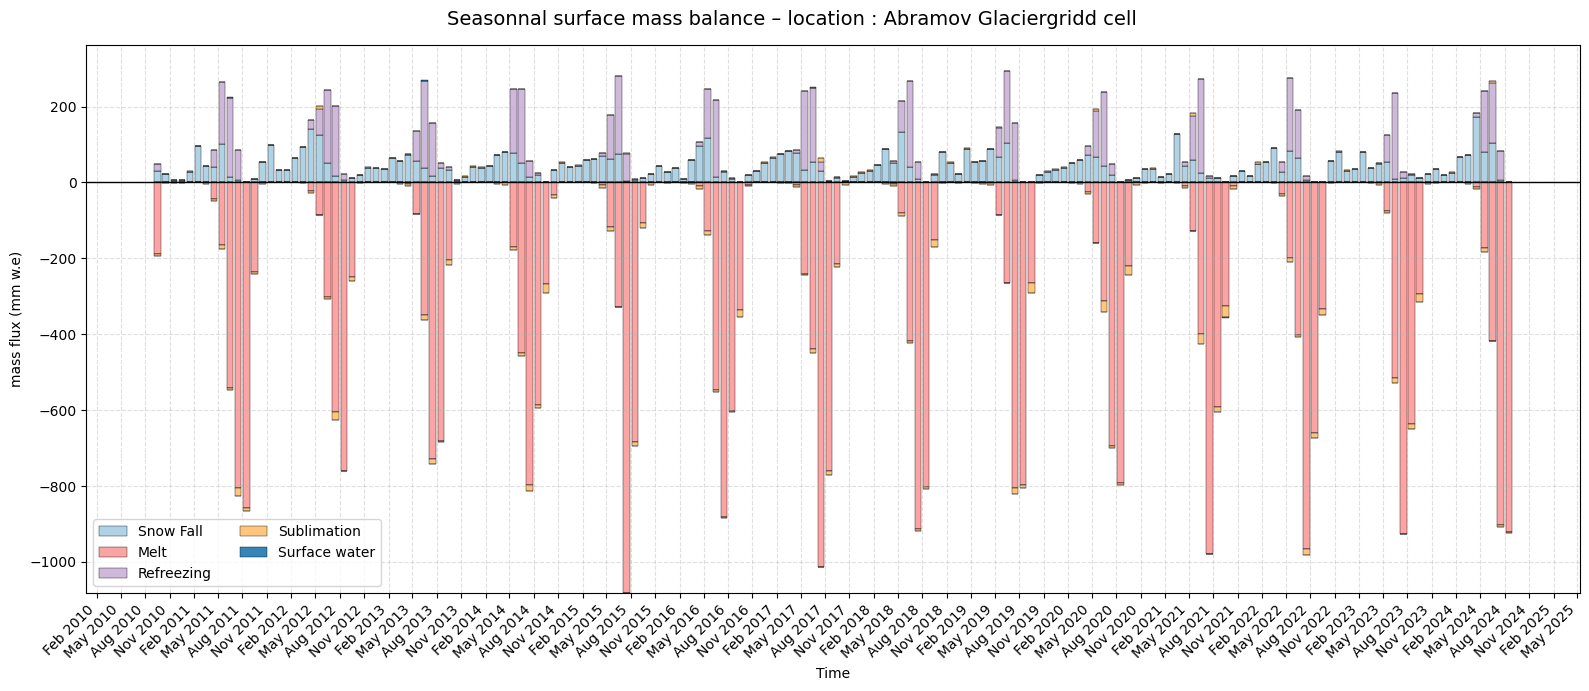

In [30]:
# Période cible
start_date = "2010-09-01"
end_date = "2024-08-31"

# Filtrer les données temporellement
smb_filtered = {}
for key, da in smb_dataset.items():
    smb_filtered[key] = da.sel(time=slice(start_date, end_date))

# Selectionner les données sur la maille ou se trouve le forage Jasgulem 2025
smb_jasg = {}
for key, da in smb_filtered.items():
    smb_jasg[key] = da.isel(Y=iY, X=iX)


# Composantes du SMB
components = ["SF", "ME", "RZ", "SU", "SW"]
labels = {
    "SF": "Snow Fall",
    "ME": "Melt",
    "RZ": "Refreezing",
    "SU": "Sublimation",
    "SW": "Surface water",
}

# Couleurs pour les histos
colors = {
    "SF": "#a6cee3",   # bleu clair 
    "ME": "#fb9a99",   # rouge clair
    "RZ": "#cab2d6",   # violet clair
    "SU": "#fdbf6f",   # orange clair
    "SW": "#1f78b4",   # bleu foncé 
}

# Temps et données
time = smb_jasg[components[0]].time.values
data = np.array([smb_jasg[comp].values for comp in components])

fig, ax = plt.subplots(figsize=(16, 7))

# Initialisation cumul
cumulative_pos = np.zeros_like(data[0])
cumulative_neg = np.zeros_like(data[0])

time_num = mdates.date2num(time)
width = np.median(np.diff(time_num)) * 0.8

for i, comp in enumerate(components):
    values = data[i]

    pos = np.where(values > 0, values, 0)
    neg = np.where(values < 0, values, 0)

    ax.bar(
        time,
        pos,
        width=width,
        bottom=cumulative_pos,
        color=colors[comp],
        label=labels[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    ax.bar(
        time,
        neg,
        width=width,
        bottom=cumulative_neg,
        color=colors[comp],
        alpha=0.9,
        edgecolor="black",
        linewidth=0.3
    )

    cumulative_pos += pos
    cumulative_neg += neg

# Ligne zéro
ax.axhline(0, color='black', linewidth=1)

# Labels
ax.set_ylabel("mass flux (mm w.e)")
ax.set_xlabel("Time")

# Format date
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.xticks(rotation=45, ha="right")
fig.suptitle(f"Seasonnal surface mass balance – location : Abramov Glaciergridd cell ", fontsize=14)

ax.legend(frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()


ax.legend(ncol=2)

plt.show()